In [5]:
# Auto-reload and imports for multiclass evaluation
%load_ext autoreload
%autoreload 2

import os
import sys
import pickle
from pathlib import Path

# Add src to path
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from src.ssamba.utilities.eval_notebook_utils import plot_per_class_probability_histograms
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)

# Add repo root to path so we can import from src
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from src.ssamba.utilities.training_utils import create_model
from src.ssamba.dataset import ONCSpectrogramDataset
from src.ssamba.utilities.inference_utils import run_inference_multiclass


def load_checkpoint_state(checkpoint_path: Path, device: torch.device):
    ckpt = torch.load(str(checkpoint_path), map_location=device)
    return ckpt['model_state_dict'] if isinstance(ckpt, dict) and 'model_state_dict' in ckpt else ckpt


def find_checkpoint(model_dir: Path) -> Path:
    candidates = [
        model_dir / "models" / "ft-cls_best_checkpoint.pth",
        model_dir / "models" / "ft-avgtok_best_checkpoint.pth",
        model_dir / "models" / "best_checkpoint.pth",
        model_dir / "ft-cls_best_checkpoint.pth",
        model_dir / "best_checkpoint.pth",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"No checkpoint found in {model_dir}")


# Using standardized run_inference_multiclass from inference_utils


def plot_confusion(cm: np.ndarray, class_names, normalize: bool = True):
    if normalize:
        denom = cm.sum(axis=1, keepdims=True) + 1e-12
        cmn = cm.astype(np.float32) / denom
        fmt = ".2f"
    else:
        cmn = cm
        fmt = "d"
    plt.figure(figsize=(10, 8))
    sns.heatmap(cmn, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix' + (' (Normalized)' if normalize else ''))
    plt.tight_layout()
    plt.show()


def per_hydrophone_metrics(y_true: np.ndarray, y_pred: np.ndarray, sources, class_names):
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'source': sources})
    rows = []
    C = len(class_names)
    for hyd, g in df.groupby('source'):
        if len(g) == 0:
            continue
        acc = float((g.y_true.values == g.y_pred.values).mean())
        # Use only labels present in this hydrophone's truth or predictions to avoid penalizing absent classes
        labels_present = sorted(set(int(v) for v in (list(g.y_true.values) + list(g.y_pred.values))))
        if len(labels_present) == 0:
            labels_present = list(range(C))
        # Weighted averages reflect class frequency; macro over present labels is also useful
        pr_w, rc_w, f1_w, _ = precision_recall_fscore_support(
            g.y_true.values,
            g.y_pred.values,
            labels=labels_present,
            average='weighted',
            zero_division=0,
        )
        pr_m, rc_m, f1_m, _ = precision_recall_fscore_support(
            g.y_true.values,
            g.y_pred.values,
            labels=labels_present,
            average='macro',
            zero_division=0,
        )
        rows.append({
            'hydrophone': hyd,
            'samples': int(len(g)),
            'accuracy': acc,
            'precision_macro': float(pr_m),
            'recall_macro': float(rc_m),
            'f1_macro': float(f1_m),
            'precision_weighted': float(pr_w),
            'recall_weighted': float(rc_w),
            'f1_weighted': float(f1_w),
        })
    return pd.DataFrame(rows).sort_values('samples', ascending=False)


def per_class_by_hydrophone_recall(y_true: np.ndarray, y_pred: np.ndarray, sources, class_names):
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'source': sources})
    recalls = {}
    for hyd, g in df.groupby('source'):
        rec = []
        for c in range(len(class_names)):
            mask = g.y_true.values == c
            denom = mask.sum()
            rec.append(float((g.y_pred.values[mask] == c).mean()) if denom > 0 else np.nan)
        recalls[hyd] = rec
    M = pd.DataFrame.from_dict(recalls, orient='index', columns=class_names)
    return M


def plot_per_class_by_hydrophone(M: pd.DataFrame):
    plt.figure(figsize=(max(12, 0.5 * len(M.columns)), max(8, 0.35 * len(M.index))))
    sns.heatmap(M, cmap='YlGnBu', vmin=0, vmax=1)
    plt.title('Per-class Recall by Hydrophone')
    plt.xlabel('Class')
    plt.ylabel('Hydrophone')
    plt.tight_layout()
    plt.show()


def compute_ovr_roc_auc(y_true: np.ndarray, proba: np.ndarray, class_names):
    C = proba.shape[1]
    y_true_onehot = np.eye(C)[y_true]
    aucs = {}
    for c in range(C):
        try:
            aucs[class_names[c]] = float(roc_auc_score(y_true_onehot[:, c], proba[:, c]))
        except Exception:
            aucs[class_names[c]] = np.nan
    macro = float(np.nanmean(list(aucs.values()))) if len(aucs) else np.nan
    return aucs, macro


def show_misclassified_examples(dataset: ONCSpectrogramDataset, y_true: np.ndarray, y_pred: np.ndarray, class_names, target_class: int = None, k: int = 8):
    idxs = np.where(y_true != y_pred)[0]
    if target_class is not None:
        idxs = [i for i in idxs if int(y_true[i]) == int(target_class)]
    idxs = idxs[:k]
    if len(idxs) == 0:
        print("No misclassified examples for selection.")
        return
    n = len(idxs)
    cols = min(4, n)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(4 * cols, 3 * rows))
    with h5py.File(dataset.data_path, 'r') as hf:
        for j, i in enumerate(idxs):
            plt.subplot(rows, cols, j + 1)
            idx_in_h5 = dataset.sample_info[i]['index']
            spec = hf['spectrograms'][idx_in_h5]
            spec = dataset.normalise(spec)
            spec = np.transpose(spec, (2, 0, 1))
            plt.imshow(spec[0], origin='lower', aspect='auto', cmap='inferno')
            lbls = dataset.sample_info[i]['labels']
            src = dataset.sample_info[i]['source']
            plt.title(f"T:{class_names[y_true[i]]} P:{class_names[y_pred[i]]}\n{src}\n{' ;'.join(lbls)[:40]}", fontsize=8)
            plt.axis('off')
    plt.tight_layout()
    plt.show()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# 1) Configure paths to your experiment and dataset
from pathlib import Path

# Example placeholders; update to your experiment
model_dir = Path("/home/sbialek/ONC/selfsupervision_anomalies_onc/data/trained-model/finetune/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-fir_experiment_multiclass_avgtok2")
checkpoint_path = find_checkpoint(model_dir)

# Load saved args used for training
with open(model_dir / "args.pkl", "rb") as f:
    args = pickle.load(f)

# Enforce multiclass settings inferred from args
assert getattr(args, 'multiclass', True), "This notebook expects a multiclass-trained model. Set args.multiclass=True."
num_classes = getattr(args, 'num_classes', None)
assert num_classes and num_classes > 1, "args.num_classes must be > 1 for multiclass."

# Path to HDF5
data_path = "/home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5"
print("Using data_path:", data_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2) Create model and load checkpoint
model = create_model(args).to(device)
state_dict = load_checkpoint_state(checkpoint_path, device)
model.load_state_dict(state_dict)
model.eval()
print("Loaded checkpoint:", checkpoint_path)

# 3) Prepare multiclass test dataset and loader
test_dataset = ONCSpectrogramDataset(
    data_path=data_path,
    split='test',
    train_ratio=args.train_ratio,
    val_ratio=args.val_ratio,
    seed=getattr(args, 'split_seed', 42),
    target_length=args.target_length,
    num_mel_bins=args.num_mel_bins,
    supervised=True,
    subsample_test=False,
    multiclass=True,
    num_classes=num_classes,
    dataset_mean=args.dataset_mean,
    dataset_std=args.dataset_std,
)

# Build class name list from dataset mapping (index_to_label)
index_to_label = getattr(test_dataset, 'index_to_label', None)
if index_to_label is None:
    # If not built yet, trigger by accessing a sample or rebuilding
    _ = test_dataset[0]
    index_to_label = test_dataset.index_to_label
class_names = [index_to_label[i] for i in range(len(index_to_label))]
print("Classes:", class_names)

test_loader = DataLoader(test_dataset, batch_size=getattr(args, 'batch_size', 4), shuffle=False, num_workers=4)



Using data_path: /home/sbialek/ONC/selfsupervision_anomalies_onc/data/different_locations_incl_backgroundpipelinenormals_multilabel.h5
Vision Mamba Config: {'img_size': (512, 512), 'patch_size': 16, 'stride': 16, 'embed_dim': 768, 'depth': 24, 'channels': 1, 'num_classes': 8, 'drop_rate': 0.0, 'drop_path_rate': 0.1, 'norm_epsilon': 1e-05, 'rms_norm': False, 'residual_in_fp32': False, 'fused_add_norm': False, 'if_rope': False, 'if_rope_residual': False, 'bimamba_type': 'v2', 'if_cls_token': True, 'if_devide_out': True, 'use_double_cls_token': False, 'use_middle_cls_token': False, 'if_bidirectional': True, 'final_pool_type': 'none', 'if_abs_pos_embed': True, 'if_bimamba': False}
Loading pretrained model from: /scratch/merileo/exp/pretrain/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-full_dataset_hydrophones_FINAL/models/pretrain-joint_best_checkpoint.pth
Loaded state dict keys: dict_keys(['epoch', 'global_step', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_

test inference:   0%|          | 0/104 [00:00<?, ?batch/s]

Overall accuracy: 0.9430
              precision    recall  f1-score   support

      normal     0.9777    0.9777    0.9777       943
     Anomaly     0.3750    0.1875    0.2500        16
    Data Gap     0.9216    0.9792    0.9495        48
     Dropout     0.7890    0.8600    0.8230       100
Engine Noise     0.9405    0.9658    0.9530       409
        Rain     0.7000    0.7241    0.7119        29
 Sensitivity     0.5000    0.5000    0.5000         2
       Tonal     0.9310    0.7864    0.8526       103

    accuracy                         0.9430      1650
   macro avg     0.7669    0.7476    0.7522      1650
weighted avg     0.9412    0.9430    0.9413      1650



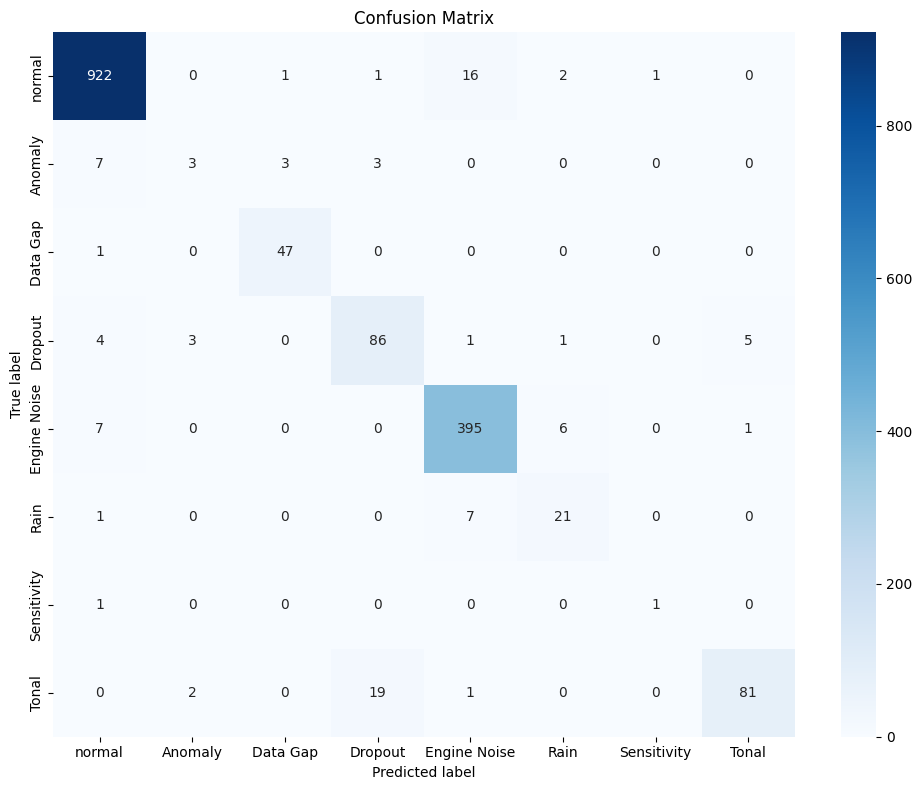

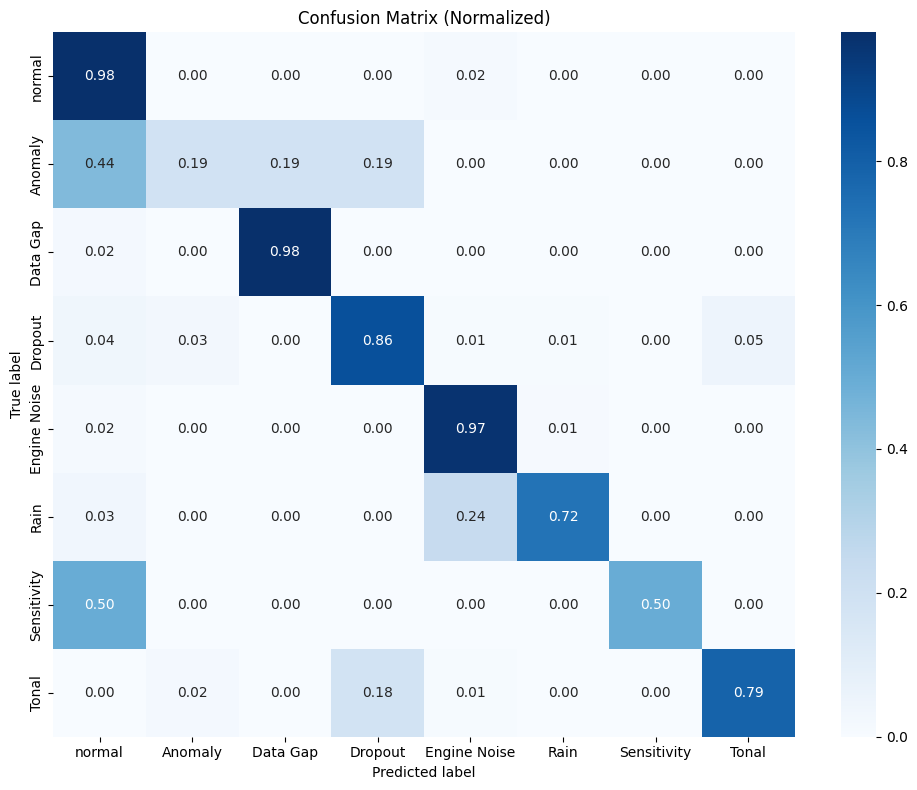

In [3]:
# 4) Run inference and compute overall metrics

y_true, y_pred, y_proba, sources = run_inference_multiclass(model, test_loader, device, task=getattr(args, 'task', 'ft_cls'), show_progress=True, desc='test inference')

# Overall accuracy
overall_acc = float((y_true == y_pred).mean())
print(f"Overall accuracy: {overall_acc:.4f}")

# Macro/micro P/R/F1
report = classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0)
print(report)

# Confusion matrices
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
plot_confusion(cm, class_names, normalize=False)
plot_confusion(cm, class_names, normalize=True)



In [13]:
# 5) Per-class metrics table and bar plots

from sklearn.metrics import precision_recall_fscore_support

pr, rc, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=np.arange(len(class_names)), zero_division=0
)
per_class_df = pd.DataFrame({
    'class': class_names,
    'precision': pr,
    'recall': rc,
    'f1': f1,
    'support': support,
}).sort_values('support', ascending=False)
per_class_df


,class,precision,recall,f1,support
0,normal,0.977731,0.977731,0.977731,943
4,Engine Noise,0.940476,0.965770,0.952955,409
7,Tonal,0.931034,0.786408,0.852632,103
3,Dropout,0.788991,0.860000,0.822967,100
2,Data Gap,0.921569,0.979167,0.949495,48
5,Rain,0.700000,0.724138,0.711864,29
1,Anomaly,0.375000,0.187500,0.250000,16
6,Sensitivity,0.500000,0.500000,0.500000,2


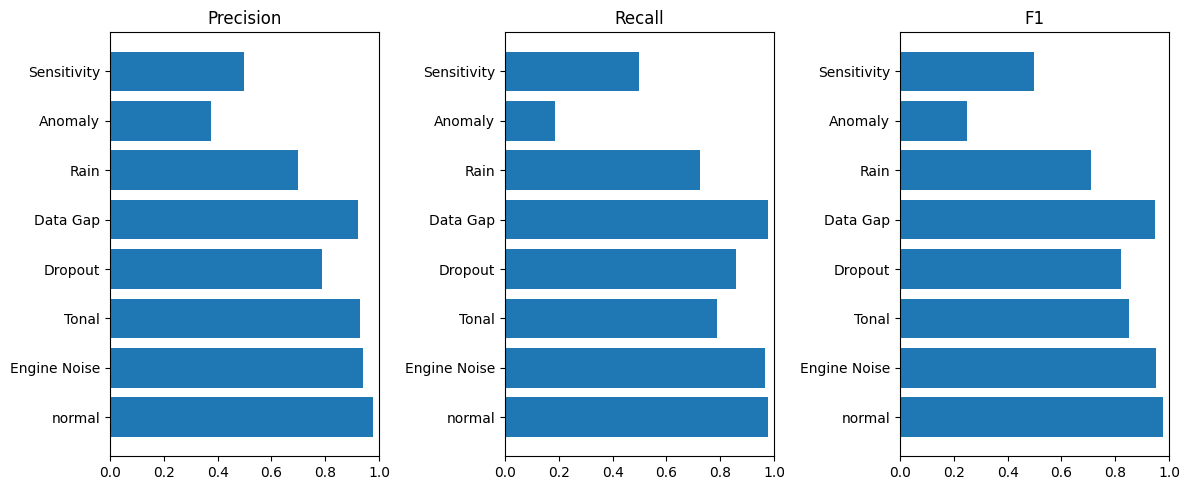

In [14]:
# 6) Bar charts of per-class metrics

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.barh(per_class_df['class'], per_class_df['precision'])
plt.title('Precision')
plt.xlim(0, 1)

plt.subplot(1, 3, 2)
plt.barh(per_class_df['class'], per_class_df['recall'])
plt.title('Recall')
plt.xlim(0, 1)

plt.subplot(1, 3, 3)
plt.barh(per_class_df['class'], per_class_df['f1'])
plt.title('F1')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


In [6]:
# 7) Per-hydrophone metrics and per-class-by-hydrophone recall heatmap

hydro_df = per_hydrophone_metrics(y_true, y_pred, sources, class_names)
hydro_df



,hydrophone,samples,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
3,ICLISTENHF1354,451,0.920177,0.811194,0.747746,0.775284,0.917107,0.920177,0.917132
1,ICLISTENHF1253,302,0.996689,0.500000,0.498344,0.499171,1.000000,0.996689,0.998342
2,ICLISTENHF1266,254,0.984252,0.985889,0.813272,0.871732,0.984248,0.984252,0.983549
9,ICLISTENHF6324,153,0.934641,0.481497,0.375316,0.393596,0.943628,0.934641,0.923664
8,ICLISTENHF6095,93,0.591398,0.304167,0.320546,0.297842,0.584140,0.591398,0.567209
4,ICLISTENHF1951,92,0.956522,0.696038,0.727244,0.709324,0.948533,0.956522,0.951525
5,ICLISTENHF6020,91,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,ICLISTENHF6094,70,0.985714,0.500000,0.492857,0.496403,1.000000,0.985714,0.992806
6,ICLISTENHF6093,63,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
11,JASCOAMARHYDROPHONED001022,33,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


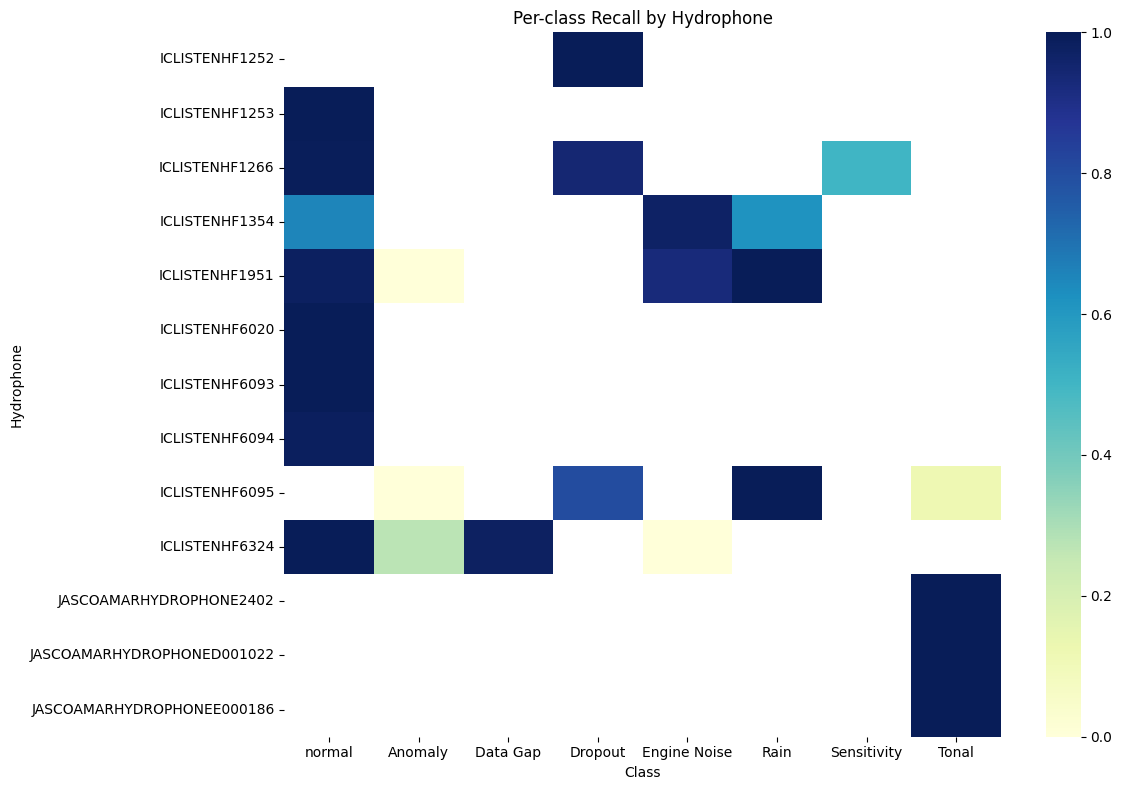

,normal,Anomaly,Data Gap,Dropout,Engine Noise,Rain,Sensitivity,Tonal
ICLISTENHF1252,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
ICLISTENHF1253,0.996689,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ICLISTENHF1266,0.995370,NaN,NaN,0.944444,NaN,NaN,0.5,NaN
ICLISTENHF1354,0.653061,NaN,NaN,NaN,0.971129,0.619048,NaN,NaN
ICLISTENHF1951,0.983051,0.000000,NaN,NaN,0.925926,1.000000,NaN,NaN
ICLISTENHF6020,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ICLISTENHF6093,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ICLISTENHF6094,0.985714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ICLISTENHF6095,NaN,0.000000,NaN,0.803279,NaN,1.000000,NaN,0.12
ICLISTENHF6324,1.000000,0.272727,0.979167,NaN,0.000000,NaN,NaN,NaN


In [16]:
# 7b) Heatmap: per-class recall by hydrophone

M = per_class_by_hydrophone_recall(y_true, y_pred, sources, class_names)
plot_per_class_by_hydrophone(M)
M


In [17]:
# 8) One-vs-rest ROC AUC per class (optional)

aucs, macro_auc = compute_ovr_roc_auc(y_true, y_proba, class_names)
print("Per-class AUC (OvR):")
for k, v in aucs.items():
    print(f"  {k:20s}: {v}")
print(f"Macro AUC: {macro_auc}")


Per-class AUC (OvR):
  normal              : 0.991697927556731
  Anomaly             : 0.9748317013463892
  Data Gap            : 0.9957344985434873
  Dropout             : 0.993341935483871
  Engine Noise        : 0.9927635454489931
  Rain                : 0.9935969707928268
  Sensitivity         : 0.9996966019417476
  Tonal               : 0.9767793599889545
Macro AUC: 0.989805317637875


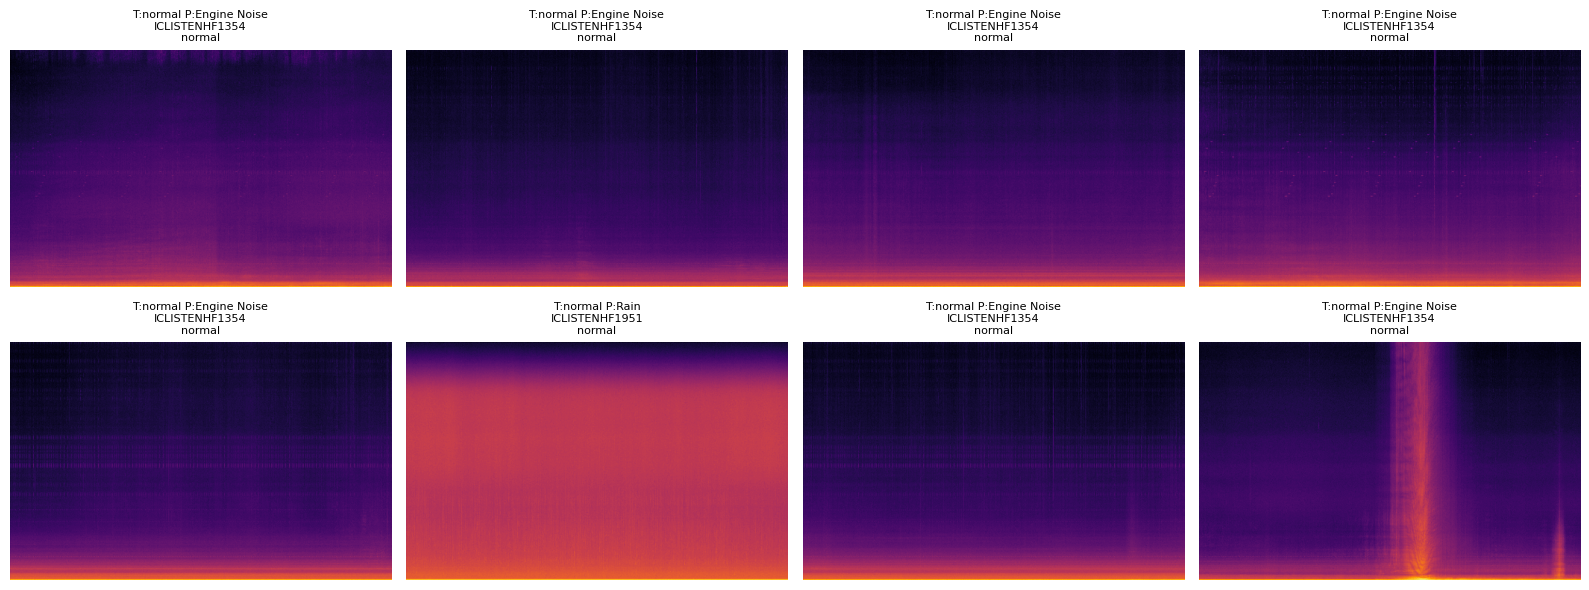

In [18]:
# 9) Misclassified examples (optional)

# Set target_class to an index to filter (e.g., 1), or None to sample all
show_misclassified_examples(test_dataset, y_true, y_pred, class_names, target_class=None, k=8)


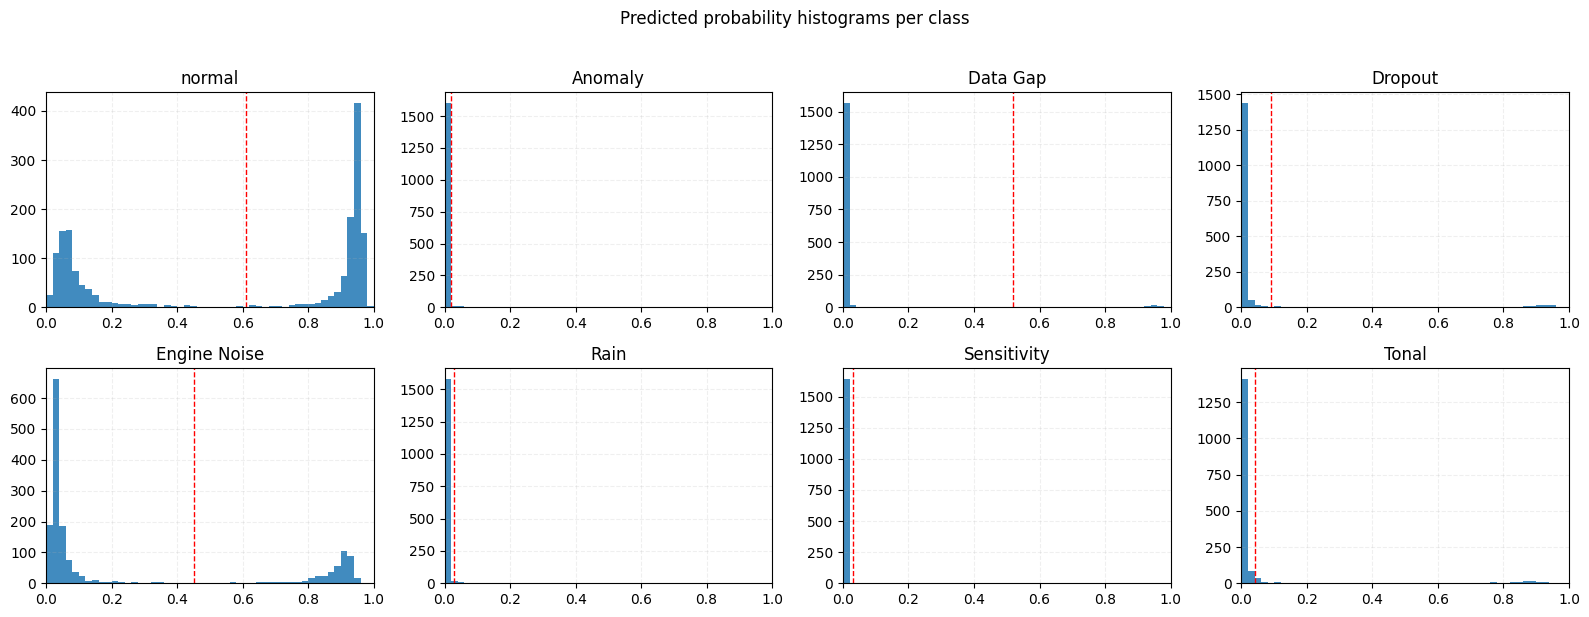

In [37]:
# Per-class probability histograms (validation/test predictions)

# Assumes you have run inference and have `y_proba` (N x C) and `class_names` (C)
# If you tuned per-class thresholds earlier, pass them too (optional)
try:
    _ = y_proba.shape
except NameError:
    raise RuntimeError("Run inference cells first to define `y_proba`.")

# If you stored per-class thresholds (e.g., best_t_per_class), use them; otherwise None
per_class_thresholds = globals().get('best_t_per_class', None)
plot_per_class_probability_histograms(y_proba, class_names, per_class_thresholds)


In [19]:
# 10) Multi-label-aware metrics (samples can have multiple true labels)

import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

C = len(class_names)

# Build ground-truth multi-label matrix (N x C)
y_true_ml = np.zeros((len(test_dataset), C), dtype=int)
for i, sample in enumerate(test_dataset.sample_info):
    for lab in sample['labels']:
        if lab is None or lab == '':
            continue
        norm = lab.strip().lower()
        if norm in ['unknown', 'unknown feature', 'unknown features']:
            lab = 'Anomaly'
        if lab in test_dataset.label_to_index:
            c = test_dataset.label_to_index[lab]
            if 0 <= c < C:
                y_true_ml[i, c] = 1

# Convert model probabilities to top-k multi-label predictions
def topk_pred(probs: np.ndarray, k: int):
    N, C = probs.shape
    topk = np.argsort(-probs, axis=1)[:, :k]
    y_pred_bin = np.zeros((N, C), dtype=int)
    for i in range(N):
        y_pred_bin[i, topk[i]] = 1
    return y_pred_bin

for k in [1, 2, 3]:
    y_pred_ml_k = topk_pred(y_proba, k)
    # Hit@k: did we get at least one of the true labels?
    hits = (y_true_ml & y_pred_ml_k).sum(axis=1) > 0
    hit_at_k = float(hits.mean())
    # Micro/macro F1 for multi-label
    f1_micro = f1_score(y_true_ml, y_pred_ml_k, average='micro', zero_division=0)
    f1_macro = f1_score(y_true_ml, y_pred_ml_k, average='macro', zero_division=0)
    prec_micro = precision_score(y_true_ml, y_pred_ml_k, average='micro', zero_division=0)
    rec_micro = recall_score(y_true_ml, y_pred_ml_k, average='micro', zero_division=0)
    print(f"Top-{k}: Hit@{k}={hit_at_k:.4f} | micro-F1={f1_micro:.4f} (P={prec_micro:.4f}, R={rec_micro:.4f}) | macro-F1={f1_macro:.4f}")


Top-1: Hit@1=0.9655 | micro-F1=0.9224 (P=0.9655, R=0.8830) | macro-F1=0.7380
Top-2: Hit@2=0.9915 | micro-F1=0.6516 (P=0.5039, R=0.9218) | macro-F1=0.6924
Top-3: Hit@3=0.9964 | micro-F1=0.5123 (P=0.3495, R=0.9590) | macro-F1=0.5058


In [ ]:
# 11) Build validation set for threshold tuning and run inference

val_dataset = ONCSpectrogramDataset(
    data_path=data_path,
    split='val',
    train_ratio=args.train_ratio,
    val_ratio=args.val_ratio,
    seed=getattr(args, 'split_seed', 42),
    target_length=args.target_length,
    num_mel_bins=args.num_mel_bins,
    supervised=True,
    subsample_test=False,
    multiclass=True,
    num_classes=num_classes,
    dataset_mean=args.dataset_mean,
    dataset_std=args.dataset_std,
)

val_loader = DataLoader(val_dataset, batch_size=getattr(args, 'batch_size', 4), shuffle=False, num_workers=4)

y_true_val, y_pred_val_tmp, y_proba_val, sources_val = run_inference_multiclass(
    model, val_loader, device, task=getattr(args, 'task', 'ft_cls'), show_progress=True, desc='val inference'
)

# Multi-label ground truth for val
C = len(class_names)
y_true_ml_val = np.zeros((len(val_dataset), C), dtype=int)
for i, sample in enumerate(val_dataset.sample_info):
    for lab in sample['labels']:
        if lab is None or lab == '':
            continue
        norm = lab.strip().lower()
        if norm in ['unknown', 'unknown feature', 'unknown features']:
            lab = 'Anomaly'
        if lab in val_dataset.label_to_index:
            c = val_dataset.label_to_index[lab]
            if 0 <= c < C:
                y_true_ml_val[i, c] = 1


Multiclass label mapping: {'normal': 0, 'Anomaly': 1, 'Data Gap': 2, 'Dropout': 3, 'Engine Noise': 4, 'Rain': 5, 'Sensitivity': 6, 'Tonal': 7}


In [23]:
# 12) Search a single global threshold maximizing micro-F1 on validation

from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.linspace(0.0, 1.0, 101)
best_t = 0.5
best_f1_micro = -1.0
best_stats = None

for t in thresholds:
    y_pred_bin = (y_proba_val >= t).astype(int)
    f1_micro = f1_score(y_true_ml_val, y_pred_bin, average='micro', zero_division=0)
    if f1_micro > best_f1_micro:
        best_f1_micro = f1_micro
        best_t = float(t)
        prec_micro = precision_score(y_true_ml_val, y_pred_bin, average='micro', zero_division=0)
        rec_micro = recall_score(y_true_ml_val, y_pred_bin, average='micro', zero_division=0)
        best_stats = (prec_micro, rec_micro)

print(f"Best global threshold: {best_t:.3f} | micro-F1={best_f1_micro:.4f} (P={best_stats[0]:.4f}, R={best_stats[1]:.4f})")


Best global threshold: 0.400 | micro-F1=0.9107 (P=0.9654, R=0.8619)


In [24]:
# 13) Per-class threshold search maximizing per-class F1 on validation

thresholds = np.linspace(0.0, 1.0, 101)
best_t_per_class = np.zeros(C, dtype=float)
best_f1_per_class = np.zeros(C, dtype=float)
best_pr_per_class = np.zeros(C, dtype=float)
best_rc_per_class = np.zeros(C, dtype=float)

for c in range(C):
    y_true_c = y_true_ml_val[:, c]
    best_f1 = -1.0
    best_t_c = 0.5
    best_pr = 0.0
    best_rc = 0.0
    if y_true_c.sum() == 0:
        # no positives in val for this class; keep default threshold
        best_t_per_class[c] = 0.5
        best_f1_per_class[c] = np.nan
        best_pr_per_class[c] = np.nan
        best_rc_per_class[c] = np.nan
        continue
    for t in thresholds:
        y_pred_c = (y_proba_val[:, c] >= t).astype(int)
        from sklearn.metrics import f1_score, precision_score, recall_score
        f1c = f1_score(y_true_c, y_pred_c, zero_division=0)
        if f1c > best_f1:
            best_f1 = f1c
            best_t_c = float(t)
            best_pr = precision_score(y_true_c, y_pred_c, zero_division=0)
            best_rc = recall_score(y_true_c, y_pred_c, zero_division=0)
    best_t_per_class[c] = best_t_c
    best_f1_per_class[c] = best_f1
    best_pr_per_class[c] = best_pr
    best_rc_per_class[c] = best_rc

thr_table = pd.DataFrame({
    'class': class_names,
    'best_threshold': best_t_per_class,
    'val_f1': best_f1_per_class,
    'val_precision': best_pr_per_class,
    'val_recall': best_rc_per_class,
})
thr_table


,class,best_threshold,val_f1,val_precision,val_recall
0,normal,0.61,0.974468,0.977240,0.971711
1,Anomaly,0.02,0.707692,0.676471,0.741935
2,Data Gap,0.52,0.957983,0.982759,0.934426
3,Dropout,0.09,0.936000,0.966942,0.906977
4,Engine Noise,0.45,0.959108,0.953202,0.965087
5,Rain,0.03,0.754386,0.811321,0.704918
6,Sensitivity,0.03,1.000000,1.000000,1.000000
7,Tonal,0.04,0.756447,0.840764,0.687500


In [33]:
thresholds

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  ])

In [25]:
# 14) Apply thresholds on test set and report multi-label metrics

# Rebuild test multi-label ground truth using mapped labels
y_true_ml_test = np.zeros((len(test_dataset), C), dtype=int)
for i, sample in enumerate(test_dataset.sample_info):
    for lab in sample['labels']:
        if lab is None or lab == '':
            continue
        norm = lab.strip().lower()
        if norm in ['unknown', 'unknown feature', 'unknown features']:
            lab = 'Anomaly'
        if lab in test_dataset.label_to_index:
            c = test_dataset.label_to_index[lab]
            if 0 <= c < C:
                y_true_ml_test[i, c] = 1

# Global threshold
y_pred_ml_test_global = (y_proba >= best_t).astype(int)

# Per-class thresholds
thr_vec = best_t_per_class.reshape(1, -1)
y_pred_ml_test_perclass = (y_proba >= thr_vec).astype(int)

from sklearn.metrics import f1_score, precision_score, recall_score

def summarize(y_true_bin, y_pred_bin, name):
    prec_micro = precision_score(y_true_bin, y_pred_bin, average='micro', zero_division=0)
    rec_micro = recall_score(y_true_bin, y_pred_bin, average='micro', zero_division=0)
    f1_micro = f1_score(y_true_bin, y_pred_bin, average='micro', zero_division=0)
    f1_macro = f1_score(y_true_bin, y_pred_bin, average='macro', zero_division=0)
    print(f"{name}: micro-F1={f1_micro:.4f} (P={prec_micro:.4f}, R={rec_micro:.4f}) | macro-F1={f1_macro:.4f}")

summarize(y_true_ml_test, y_pred_ml_test_global, 'Test (global thr)')
summarize(y_true_ml_test, y_pred_ml_test_perclass, 'Test (per-class thr)')


Test (global thr): micro-F1=0.9220 (P=0.9666, R=0.8814) | macro-F1=0.7255
Test (per-class thr): micro-F1=0.9313 (P=0.9342, R=0.9285) | macro-F1=0.8087


### Notes on metrics in this report

- **Micro vs Macro F1**
  - **Micro F1**: aggregate TP/FP/FN over all classes before computing precision/recall/F1; favors frequent classes.
  - **Macro F1**: average F1 computed per class; treats each class equally; sensitive to rare classes.
- **Support**: number of ground-truth instances for a class (used for understanding class imbalance).
- **Top-N hits**: for multi-label, we sometimes treat the top-k predicted labels as the model’s outputs. **Hit@k** measures if at least one of the true labels appears in top-k predictions.
- **Thresholding for multi-label**: alternatively, predict all classes whose probability exceeds a threshold (single global threshold or per-class thresholds). We tune thresholds on the validation set.


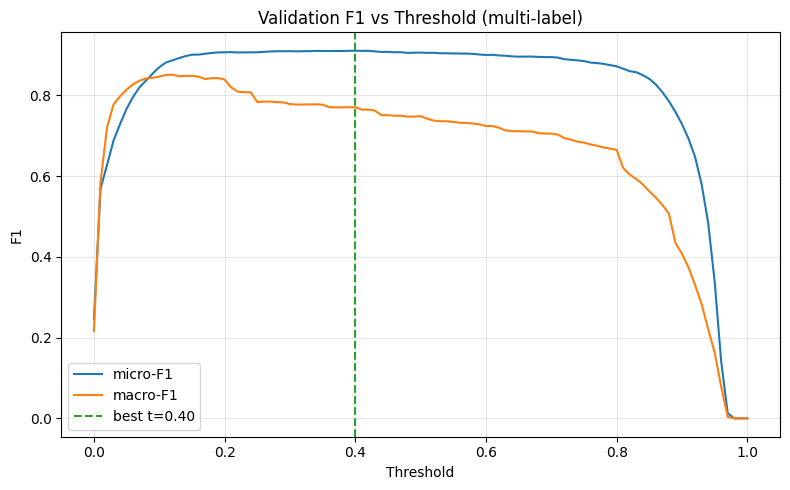

In [26]:
# 15) Plot F1 vs threshold on validation (multi-label thresholding)

ths = np.linspace(0.0, 1.0, 101)
f1_micro_vals = []
f1_macro_vals = []

for t in ths:
    y_pred_bin = (y_proba_val >= t).astype(int)
    f1_micro_vals.append(f1_score(y_true_ml_val, y_pred_bin, average='micro', zero_division=0))
    f1_macro_vals.append(f1_score(y_true_ml_val, y_pred_bin, average='macro', zero_division=0))

f1_micro_vals = np.array(f1_micro_vals)
f1_macro_vals = np.array(f1_macro_vals)

best_idx = int(np.argmax(f1_micro_vals))
plt.figure(figsize=(8, 5))
plt.plot(ths, f1_micro_vals, label='micro-F1', color='tab:blue')
plt.plot(ths, f1_macro_vals, label='macro-F1', color='tab:orange')
plt.axvline(ths[best_idx], color='tab:green', linestyle='--', label=f'best t={ths[best_idx]:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1')
plt.title('Validation F1 vs Threshold (multi-label)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


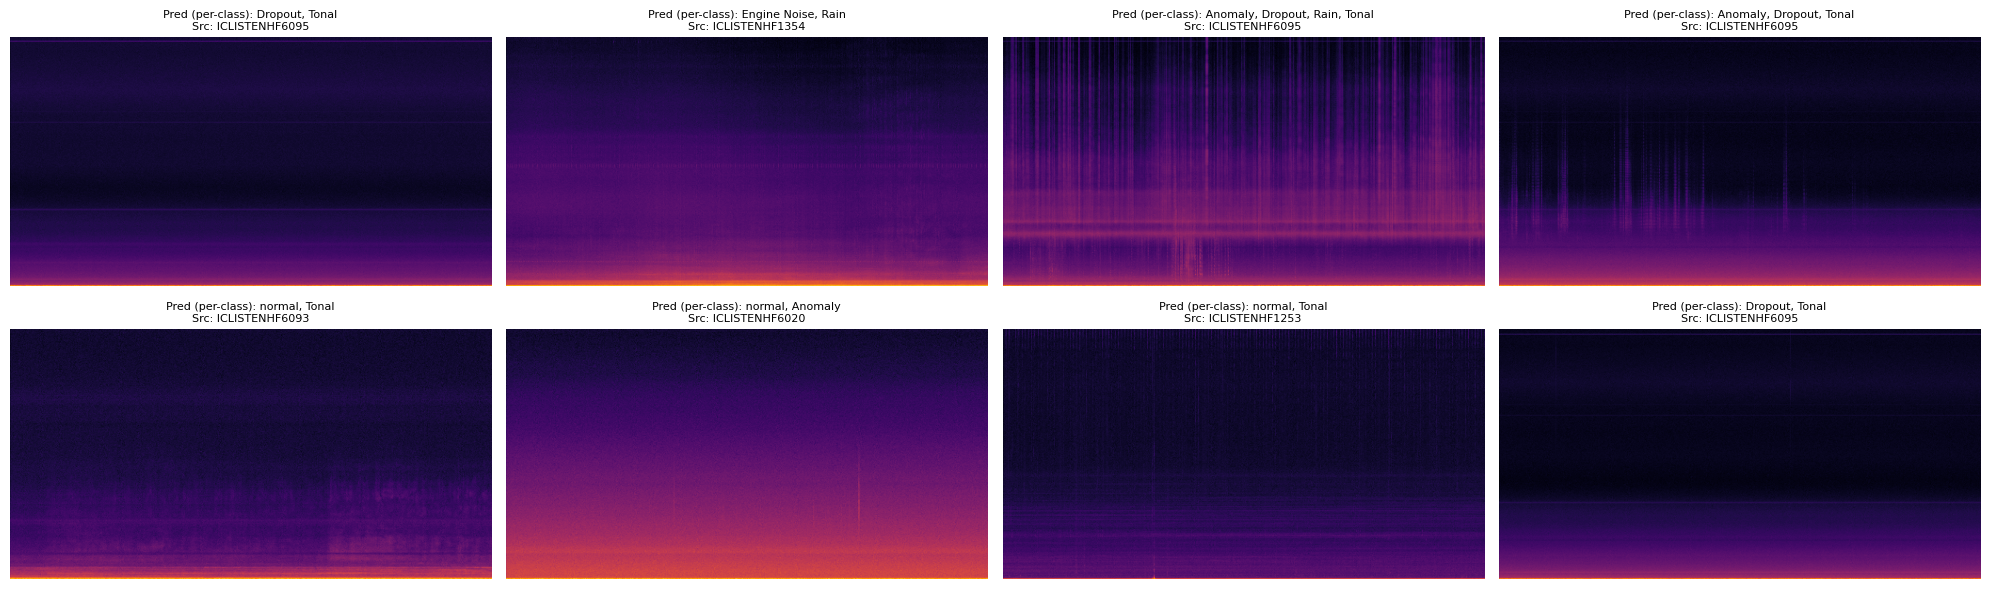

In [30]:
# 16) Display test spectrograms with multiple predicted labels and show truth labels

import random

def display_multi_label_predictions(dataset, y_pred_bin, class_names, k=8, samples_per_row=4, threshold_name='per-class'):
    idxs = [i for i in range(len(dataset)) if y_pred_bin[i].sum() >= 2]
    if len(idxs) == 0:
        print("No samples with >=2 predicted labels found.")
        return
    random.seed(2)
    idxs = random.sample(idxs, min(k, len(idxs)))
    rows = int(np.ceil(len(idxs) / samples_per_row))
    plt.figure(figsize=(5 * samples_per_row, 3 * rows))
    with h5py.File(dataset.data_path, 'r') as hf:
        for j, i in enumerate(idxs):
            plt.subplot(rows, samples_per_row, j + 1)
            sample = dataset.sample_info[i]
            spec = hf['spectrograms'][sample['index']]
            spec = dataset.normalise(spec)
            spec = np.transpose(spec, (2, 0, 1))
            plt.imshow(spec[0], origin='lower', aspect='auto', cmap='inferno')
            pred_idx = np.where(y_pred_bin[i] == 1)[0]
            pred_labels = [class_names[t] for t in pred_idx]
            true_labels = sample['labels']
            src = sample.get('source', None)
            title = f"Pred ({threshold_name}): " + ', '.join(pred_labels[:5])
            if len(pred_labels) > 5:
                title += " +"
            if src:
                title += f"\nSrc: {src}"
            plt.title(title, fontsize=8)
            # Show truth labels under the image
            truth_text = ';'.join(true_labels)
            plt.xlabel(f"Truth: {truth_text[:80]}", fontsize=7)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

# Prefer per-class thresholds if available
if 'y_pred_ml_test_perclass' in globals():
    bin_preds = y_pred_ml_test_perclass
    thr_name = 'per-class'
else:
    thr = best_t if 'best_t' in globals() else 0.5
    bin_preds = (y_proba >= thr).astype(int)
    thr_name = f'global t={thr:.2f}'

display_multi_label_predictions(test_dataset, bin_preds, class_names, k=8, samples_per_row=4, threshold_name=thr_name)


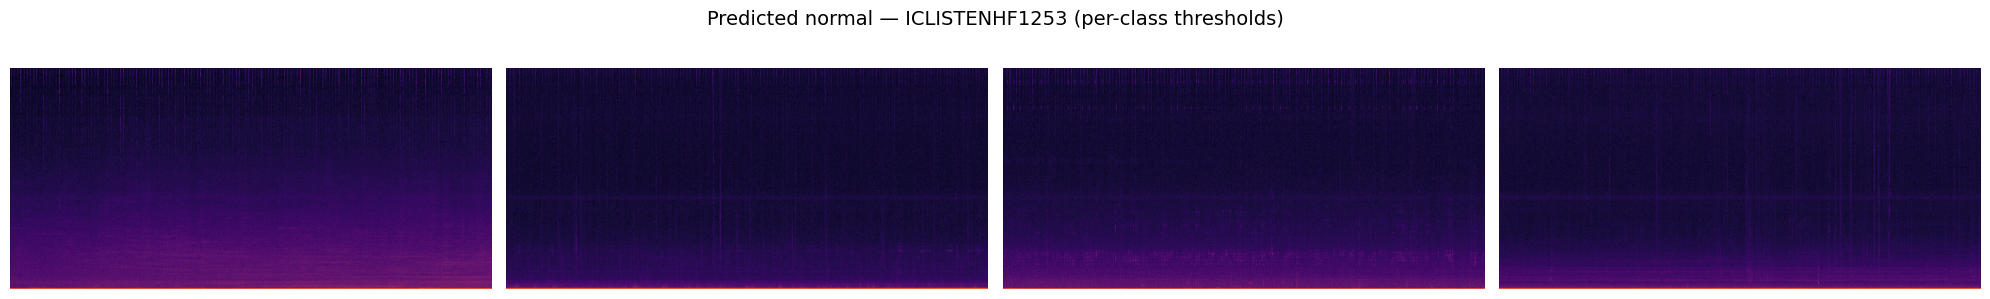

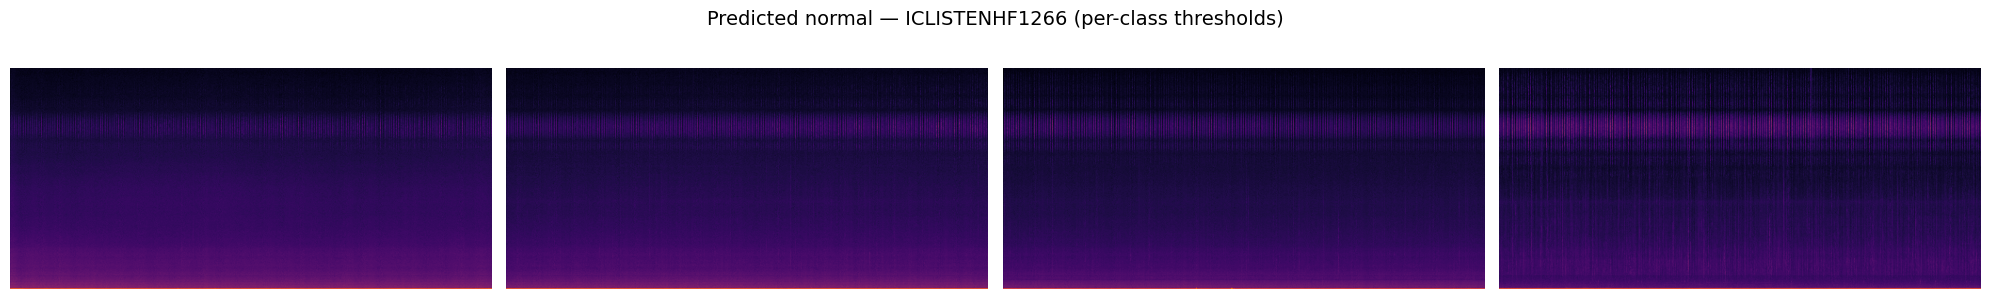

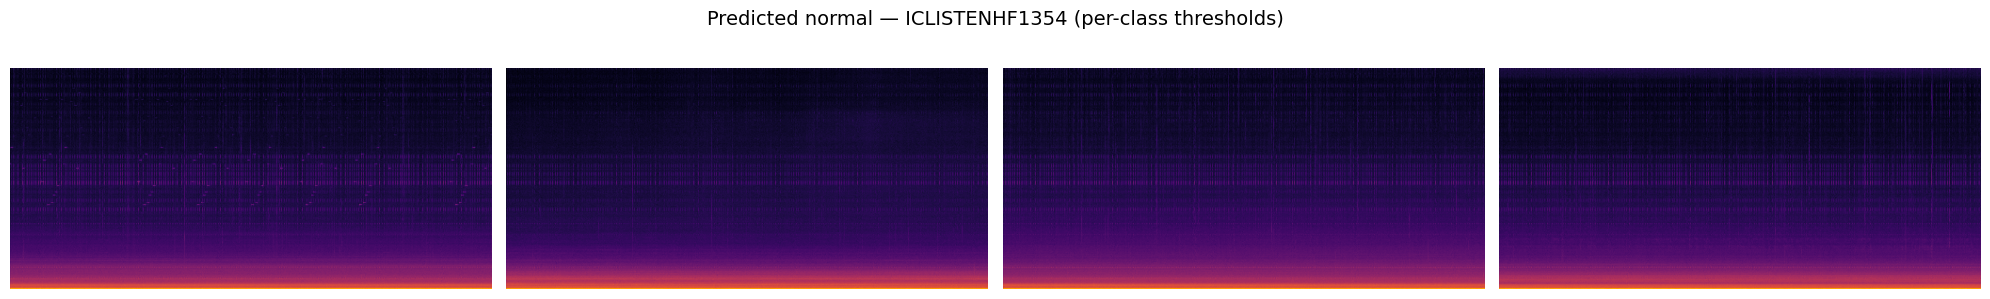

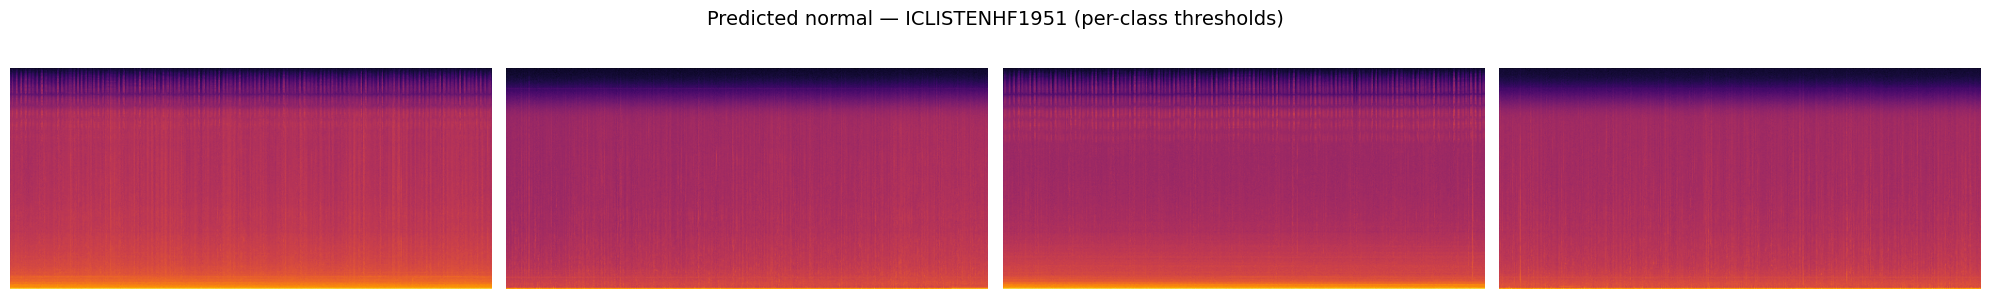

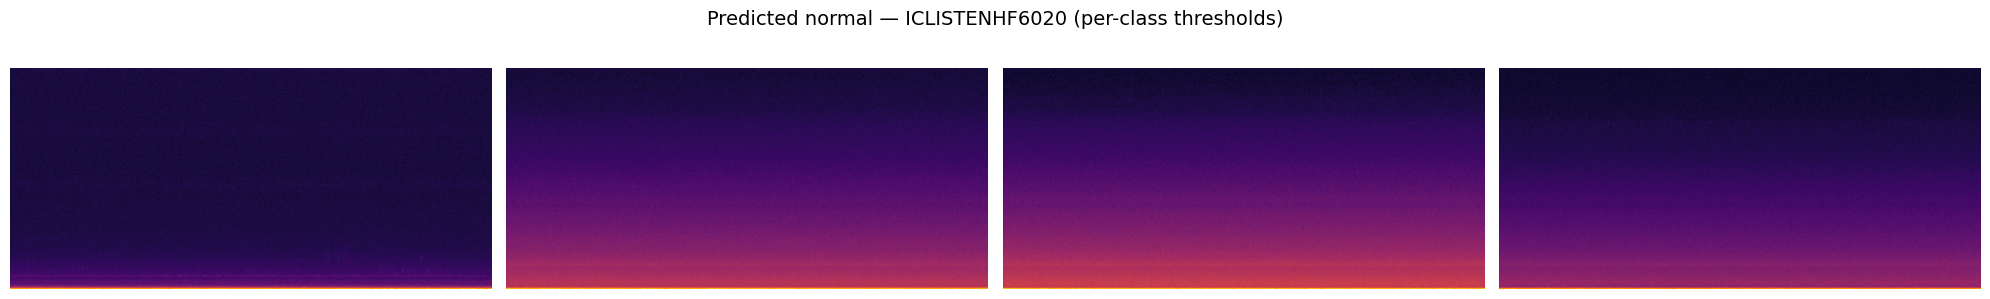

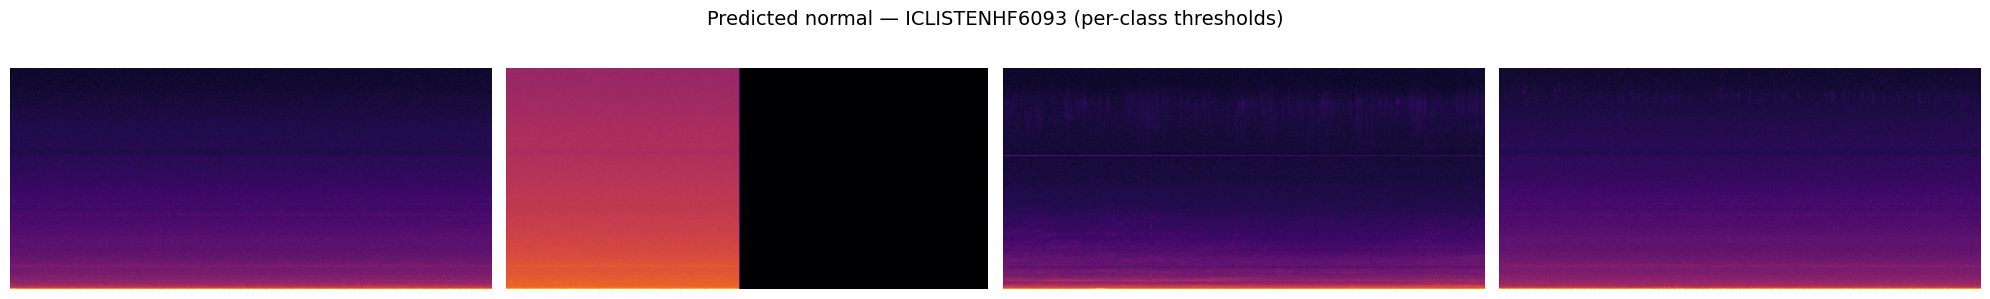

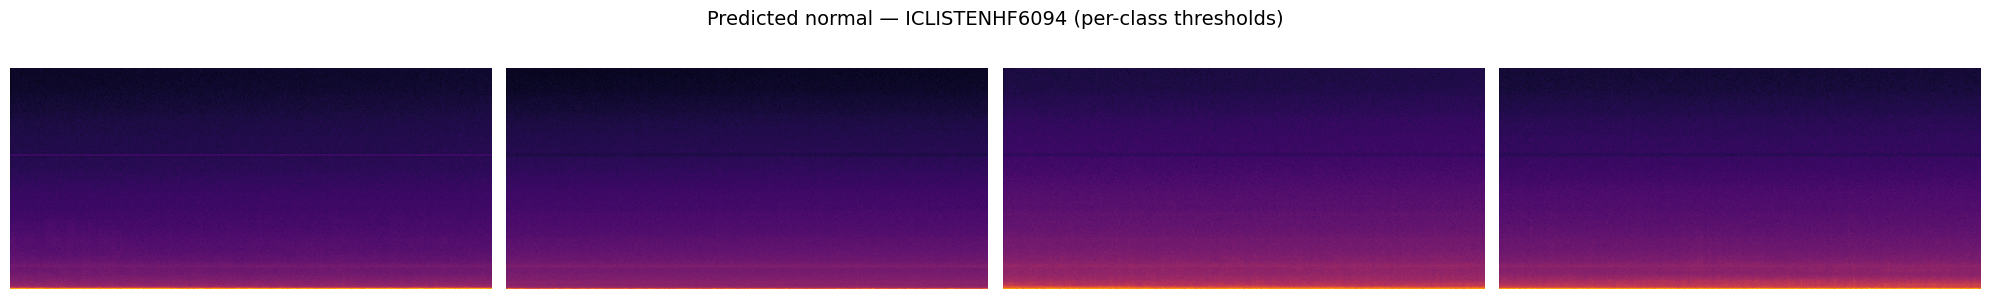

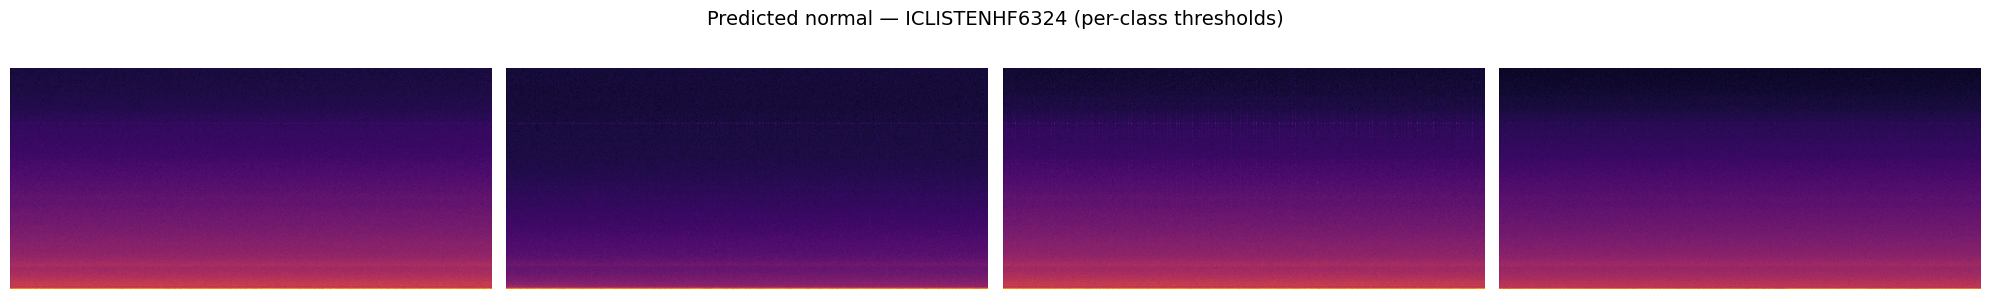

In [32]:
# 17) Show spectrograms predicted as normal (only 'normal' predicted) per hydrophone

import numpy as np

def show_predicted_normal_by_hydrophone(dataset, class_names, per_hyd_count=4, samples_per_row=4):
    # Find index of 'normal' class
    normal_idx = None
    for i, name in enumerate(class_names):
        if str(name).strip().lower() == 'normal':
            normal_idx = i
            break
    if normal_idx is None:
        print("No 'normal' class found in class_names.")
        return

    # Choose predictions: prefer per-class thresholds, else global threshold, else argmax
    if 'y_pred_ml_test_perclass' in globals():
        bin_preds = y_pred_ml_test_perclass
        pred_desc = 'per-class thresholds'
    elif 'best_t' in globals():
        bin_preds = (y_proba >= best_t).astype(int)
        pred_desc = f'global threshold t={best_t:.2f}'
    else:
        # Fallback to argmax to decide predicted class
        bin_preds = np.zeros((len(dataset), len(class_names)), dtype=int)
        if 'y_pred' in globals():
            bin_preds[np.arange(len(y_pred)), y_pred] = 1
            pred_desc = 'argmax class'
        else:
            print('No predictions available to derive predicted-normal samples.')
            return

    hydros = sorted(list({s.get('source', None) for s in dataset.sample_info if s.get('source', None)}))
    if not hydros:
        print("No hydrophone source info available.")
        return

    with h5py.File(dataset.data_path, 'r') as hf:
        found_any = False
        for hyd in hydros:
            # Predicted-only-normal samples for this hydrophone
            idxs = [i for i, s in enumerate(dataset.sample_info)
                    if s.get('source', None) == hyd and bin_preds[i, normal_idx] == 1 and bin_preds[i].sum() == 1]
            if len(idxs) == 0:
                continue
            found_any = True
            sel = idxs[:per_hyd_count]
            rows = int(np.ceil(len(sel) / samples_per_row))
            plt.figure(figsize=(5 * samples_per_row, 3 * rows))
            plt.suptitle(f"Predicted normal — {hyd} ({pred_desc})", fontsize=14)
            for j, i in enumerate(sel):
                plt.subplot(rows, samples_per_row, j + 1)
                sample = dataset.sample_info[i]
                spec = hf['spectrograms'][sample['index']]
                spec = dataset.normalise(spec)
                spec = np.transpose(spec, (2, 0, 1))
                plt.imshow(spec[0], origin='lower', aspect='auto', cmap='inferno')
                truth_text = ';'.join(sample.get('labels', []))
                plt.xlabel(f"Truth: {truth_text[:80]}", fontsize=7)
                plt.axis('off')
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()
        if not found_any:
            print("No samples predicted as only 'normal' found.")

show_predicted_normal_by_hydrophone(test_dataset, class_names, per_hyd_count=4, samples_per_row=4)
